In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

## 0. Generate step-function dataset

In [2]:
torch.manual_seed(0)

N = 100
x = torch.linspace(-2, 2, N).reshape(-1, 1)

# Step function: y = 0 if x < 0, y = 1 if x >= 0
y = (x >= 0).float()

# Smooth grid for plotting
x_plot = torch.linspace(-2.5, 2.5, 100).reshape(-1, 1)
y_true_plot = (x_plot >= 0).float()

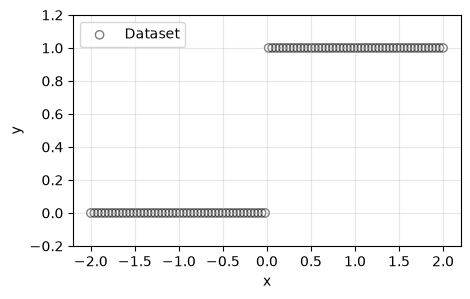

In [3]:
# ============================================================
# Visualization: 1 x 3 subplots
# ============================================================
fig, axes = plt.subplots(1, figsize=(5, 3))


# ------------------------------------------------------------
# 1) Linear regression fails
# ------------------------------------------------------------
ax = axes

ax.scatter(
    x.numpy(),
    y.numpy(),
    color="black",
    alpha=0.5,
    label="Dataset",
    facecolors="none",   # empty inside       
)

# ax.set_title("Linear Case")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_ylim(-0.2, 1.2)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10,loc='upper left')

plt.show()



## 1. Linear regression model


In [4]:
linear_model     = nn.Linear(1, 1)
linear_optimizer = torch.optim.Adam(linear_model.parameters(), lr=0.01)
mse_loss         = nn.MSELoss()

In [5]:
linear_loss_history = []

for step in range(1000):
    y_pred = linear_model(x)
    loss = mse_loss(y_pred, y)

    linear_optimizer.zero_grad()
    loss.backward()
    linear_optimizer.step()

    linear_loss_history.append(loss.item())


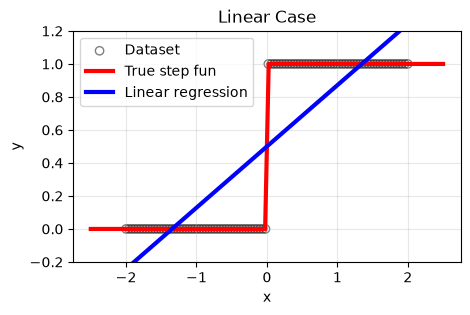

In [6]:
# ============================================================
# Visualization: 1 x 3 subplots
# ============================================================
fig, axes = plt.subplots(1, figsize=(5, 3))



# ============================================================
# Prediction for visualization
# ============================================================
with torch.no_grad():
    y_linear_plot = linear_model(x_plot)




ax = axes

ax.scatter(
    x.numpy(),
    y.numpy(),
    color="black",
    alpha=0.5,
    label="Dataset",
    facecolors="none",   # empty inside       
)

ax.plot(
    x_plot.numpy(),
    y_true_plot.numpy(),
    color="red",
    linewidth=3,
    label="True step fun"
)

ax.plot(
    x_plot.numpy(),
    y_linear_plot.numpy(),
    color="blue",
    linewidth=3,
    label="Linear regression"
)

ax.set_title("Linear Case")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_ylim(-0.2, 1.2)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

plt.show()

## 2. Linear regression with non-linear feature

In [7]:
# ============================================================
#  nonlinear features: phi(x) = [x, x^3]
# ============================================================

import torch
import torch.nn as nn

def cubic_feature(x):
    return torch.cat([x, x**3], dim=1)


feature_model    = nn.Linear(2, 1)
feature_optimizer = torch.optim.AdamW(feature_model.parameters(), lr=0.01)
mse_loss          = nn.MSELoss()


In [8]:

feature_loss_history = []

x_feature = cubic_feature(x)

for step in range(1000):
    logits  = feature_model(x_feature)
    loss    = mse_loss(logits, y)

    feature_optimizer.zero_grad()
    loss.backward()
    feature_optimizer.step()

    feature_loss_history.append(loss.item())

    if step % 100 == 0:
        print(f"Step {step+1:04d}: Loss = {loss.item():.4f}")

# ============================================================
# Prediction for visualization
# ============================================================
with torch.no_grad():
    x_plot_feature = cubic_feature(x_plot)
    y_feature_plot = feature_model(x_plot_feature)
    
    


Step 0001: Loss = 7.6126
Step 0101: Loss = 0.1344
Step 0201: Loss = 0.1012
Step 0301: Loss = 0.0808
Step 0401: Loss = 0.0644
Step 0501: Loss = 0.0526
Step 0601: Loss = 0.0450
Step 0701: Loss = 0.0404
Step 0801: Loss = 0.0378
Step 0901: Loss = 0.0364


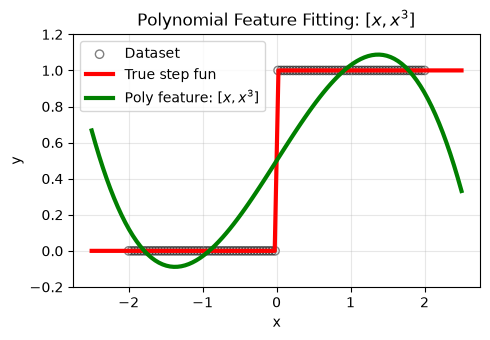

In [9]:
# ============================================================
# 5. Visualization: dataset + polynomial feature fitting
# ============================================================
fig, axes = plt.subplots(1, 1, figsize=(5, 3.5))

# ------------------------------------------------------------
# 1) Polynomial feature fitting
# ------------------------------------------------------------
ax = axes

ax.scatter(
    x.numpy(),
    y.numpy(),
    facecolors="none",
    edgecolors="black",
    alpha=0.5,
    label="Dataset",
)

ax.plot(
    x_plot.numpy(),
    y_true_plot.numpy(),
    color="red",
    linewidth=3,
    label="True step fun",
)

ax.plot(
    x_plot.numpy(),
    y_feature_plot.numpy(),
    color="green",
    linewidth=3,
    label=r"Poly feature: $[x, x^3]$",
)

ax.set_title(r"Polynomial Feature Fitting: $[x, x^3]$")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_ylim(-0.2, 1.2)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)


plt.tight_layout()
fig.savefig("reg2-poly-feature.png", dpi=300, bbox_inches="tight")
plt.show()

## 3. Three-layer MLP model


In [10]:
class ThreeLayerMLP(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.net(x)



In [11]:
mlp_model = ThreeLayerMLP(hidden_dim=64)
mlp_model




#mlp_optimizer = torch.optim.SGD(mlp_model.parameters(), lr=0.01)
mlp_optimizer = torch.optim.AdamW(mlp_model.parameters(), lr=0.01)
mse_loss      = nn.MSELoss()

mlp_loss_history = []

for step in range(1000):
    logits = mlp_model(x)
    loss   = mse_loss(logits, y)

    mlp_optimizer.zero_grad()
    loss.backward()
    mlp_optimizer.step()

    mlp_loss_history.append(loss.item())
    
    if step % 100 == 0:
        print(f"Step {step+1:04d}: Loss = {loss.item():.4f}")
    
    
# ============================================================
# Prediction for visualization
# ============================================================
with torch.no_grad():
    y_linear_plot   = linear_model(x_plot)
    y_mlp_plot      = mlp_model(x_plot)

Step 0001: Loss = 0.6026
Step 0101: Loss = 0.0054
Step 0201: Loss = 0.0023
Step 0301: Loss = 0.0012
Step 0401: Loss = 0.0002
Step 0501: Loss = 0.0000
Step 0601: Loss = 0.0000
Step 0701: Loss = 0.0000
Step 0801: Loss = 0.0001
Step 0901: Loss = 0.0000


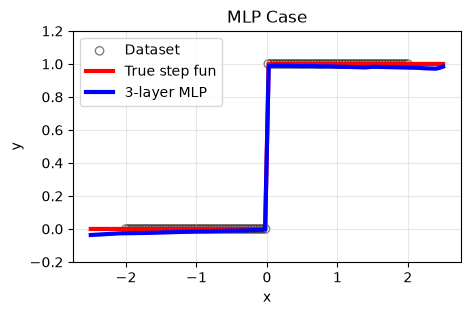

In [12]:
# ============================================================
# Visualization: 1 x 3 subplots
# ============================================================
fig, axes = plt.subplots(1, 1, figsize=(5, 3))


ax = axes
ax.scatter(
    x.numpy(),
    y.numpy(),
    color="black",
    alpha=0.5,
    label="Dataset",
    facecolors="none",   # empty inside    
)

ax.plot(
    x_plot.numpy(),
    y_true_plot.numpy(),
    color="red",
    linewidth=3,
    label="True step fun"
)

ax.plot(
    x_plot.numpy(),
    y_mlp_plot.numpy(),
    color="blue",
    linewidth=3,
    label="3-layer MLP"
)

ax.set_title("MLP Case")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_ylim(-0.2, 1.2)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

plt.show()


## 4. loss history visualization

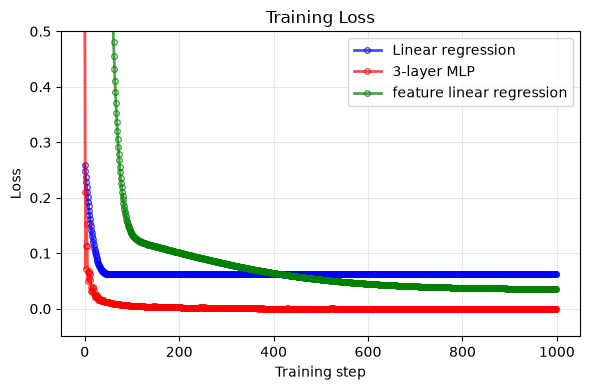

In [13]:
fig, axes = plt.subplots(1, 1, figsize=(6, 4))

# ------------------------------------------------------------
# Training loss
# ------------------------------------------------------------
ax = axes

ax.plot(
    linear_loss_history,
    color="blue",
    linestyle="-", marker="o",    markerfacecolor="none",
    markersize= 4,    
    alpha=0.7,
    linewidth=2,
    label="Linear regression",

)

ax.plot(
    mlp_loss_history,
    color="red",
    linestyle="-", marker="o",    markerfacecolor="none",
    markersize= 4,
    alpha=0.7,
    linewidth=2,
    label="3-layer MLP",

)


ax.plot(
    feature_loss_history,
    color="green",
    linestyle="-", marker="o",    markerfacecolor="none",
    markersize= 4,    
    alpha=0.7,
    linewidth=2,
    label="feature linear regression",
)

ax.set_title("Training Loss")
ax.set_xlabel("Training step")
ax.set_ylabel("Loss")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

ax.set_ylim(-0.05, .5)
# ------------------------------------------------------------
# Save and show
# ------------------------------------------------------------
plt.tight_layout(w_pad=1)
fig.savefig("reg2-results.png", dpi=300, bbox_inches="tight")
plt.show()